In [ ]:
from pathlib import Path
import json
import matplotlib as mpl
import matplotlib.pyplot as plt

EXPORT_ROOT = Path("paper_exports")
EXPORT_TABLES = EXPORT_ROOT / "tables"
EXPORT_FIGS = EXPORT_ROOT / "figures"
EXPORT_LOGS = EXPORT_ROOT / "logs"
for p in [EXPORT_ROOT, EXPORT_TABLES, EXPORT_FIGS, EXPORT_LOGS]:
    p.mkdir(parents=True, exist_ok=True)

mpl.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 900,
    "savefig.transparent": False,
    "savefig.bbox": "tight",
    "savefig.pad_inches": 0.05,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.linestyle": "--",
    "grid.alpha": 0.35,
    "font.size": 10
})

print("Figures:", EXPORT_FIGS.resolve())
print("Tables:", EXPORT_TABLES.resolve())
print("Logs:", EXPORT_LOGS.resolve())


cr = Path("current_run.txt")
run_rel = cr.read_text().strip()
RUN_PATH = Path("experiments") / Path(run_rel)

CONFIG_PATH = RUN_PATH / "config.json"
if not CONFIG_PATH.exists():
    raise RuntimeError(f"config.json not found at {CONFIG_PATH}. Make sure the run is prepared.")

CONFIG = json.load(open(CONFIG_PATH))
RESULTS_PATH = RUN_PATH / "results"


Figures: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures
Tables: C:\Projects\multimodal_realestate_ml_public\paper_exports\tables
Logs: C:\Projects\multimodal_realestate_ml_public\paper_exports\logs


# ABLATION

#### common helper methods for ablation runs

In [2]:
import numpy as np
import pandas as pd
import time
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error
from sklearn.base import clone

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

sar_df = sar_df.reindex(df_w.index).ffill()
sent_df = sent_df.reindex(df_w.index).ffill()
ir_series = ir_series.reindex(df_w.index).ffill()

selected_master_projects = [
    "Business Bay", "DAMAC HILLS 2", "DAMAC HILLS", "TOWN SQUARE", "DownTown Dubai",
    "Dubai Creek Harbour", "Dubai Marina", "Dubai South Residential District",
    "Dubai Sports City", "Al Furjan", "International City Phase 1", "Jumeirah Lakes Towers",
    "Jumeirah Village Circle", "Jumeirah Village Triangle", "Jumeriah Beach Residence  - JBR",
    "Mudon", "Palm Jumeirah", "Silicon Oasis", "The Greens"
]

region_targets = selected_master_projects + ["Global"]

sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value" or c.startswith("nsi_") or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

region_sat_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}

window = 12
horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]

modalities_order = ["P", "C", "S", "B", "I", "G"]
order_index = {m: i for i, m in enumerate(modalities_order)}

def canonicalize_tag(tag):
    letters = sorted(list(set(tag)), key=lambda x: order_index[x])
    return "".join(letters)

def build_flat_ir(tag, h, tgt):
    X = []
    y = []
    d = []
    sat_cols = region_sat_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag and sat_cols:
            parts.append(sar_df.iloc[i][sat_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if not parts:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

def eval_knn_tag_mae(tag_label, tick_every=50):
    tag = canonicalize_tag(tag_label)
    maes_all = []
    total_local = len(region_targets) * len(horizons)
    done_local = 0
    t0 = time.perf_counter()
    print(f"[Start] {tag_label} (canonical={tag})")
    for reg in region_targets:
        for h in horizons:
            Xf, yf, idx = build_flat_ir(tag, h, reg)
            if Xf.shape[0] == 0 or Xf.shape[1] == 0:
                done_local += 1
                continue
            folds = make_rolling_folds(idx)
            for tr, va, _, _, _ in folds:
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                maes_all.append(mean_absolute_error(yf[va], pred))
            done_local += 1
            if tick_every is not None and tick_every > 0:
                if done_local % tick_every == 0 or done_local == total_local:
                    pct = 100.0 * done_local / total_local
                    print(f"  [{tag_label}] {done_local}/{total_local} ({pct:.1f}%)")
    elapsed = time.perf_counter() - t0
    print(f"[Done ] {tag_label} in {elapsed:.1f}s")
    if len(maes_all) == 0:
        return np.nan
    return float(np.mean(maes_all))


# Extra Ablation Studies

## Satellite Data Ablation : NDBI vs SAR

In [ ]:
import random

SEED = 0
random.seed(SEED)
np.random.seed(SEED)

print("B-modality KNN ablation started")

df_w = pd.read_csv("1-transaction-data/price_series.csv", index_col="date", parse_dates=True)
counts_df = pd.read_csv("1-transaction-data/counts_series.csv", index_col="date", parse_dates=True)
sent_df = pd.read_csv("2-sentiment-data/nsi_features_smooth_finbert.csv", index_col="date", parse_dates=True)
sar_df = pd.read_csv("3-satellite-data/weekly_sar_aligned.csv", index_col="date", parse_dates=True)
ndbi_df = pd.read_csv("3-satellite-data/weekly_ndbi_aligned.csv", index_col="date", parse_dates=True)
ir_series = pd.read_csv("4-interest-rate-data/interest_rate_series.csv", index_col="date", parse_dates=True).squeeze("columns")

df_w = df_w.asfreq("W-SUN")
counts_df = counts_df.asfreq("W-SUN")

sar_df = sar_df.reindex(df_w.index).ffill().bfill()
ndbi_df = ndbi_df.reindex(df_w.index).ffill().bfill()
sent_df = sent_df.reindex(df_w.index).ffill().bfill()
ir_series = ir_series.reindex(df_w.index).ffill().bfill()

selected_master_projects = [
    "Business Bay",
    "DAMAC HILLS 2",
    "DAMAC HILLS",
    "TOWN SQUARE",
    "DownTown Dubai",
    "Dubai Creek Harbour",
    "Dubai Marina",
    "Dubai South Residential District",
    "Dubai Sports City",
    "Al Furjan",
    "International City Phase 1",
    "Jumeirah Lakes Towers",
    "Jumeirah Village Circle",
    "Jumeirah Village Triangle",
    "Jumeriah Beach Residence  - JBR",
    "Mudon",
    "Palm Jumeirah",
    "Silicon Oasis",
    "The Greens"
]

region_targets = selected_master_projects + ["Global"]

region_sar_cols = {r: [c for c in sar_df.columns if c.startswith(f"{r}__")] for r in region_targets}
region_ndbi_cols = {r: [c for c in ndbi_df.columns if c.startswith(f"{r}__")] for r in region_targets}

sent_cols = [
    c for c in sent_df.columns
    if c == "nsi_value"
    or c.startswith("nsi_")
    or (c.startswith("sem_pca") and c.endswith("_smooth"))
]

window = 12
all_horizons = [2, 6, 10, 14, 18, 22, 26, 30, 34]
long_horizons = [h for h in all_horizons if h >= 24]

configs = [
    {"name": "PCS",            "tag": "PCS",    "b_source": "none"},
    {"name": "PCSB_SAR",       "tag": "PCSB",   "b_source": "sar"},
    {"name": "PCSB_NDBI",      "tag": "PCSB",   "b_source": "ndbi"},
    {"name": "PCSBIG_noB",     "tag": "PCSBIG", "b_source": "none"},
    {"name": "PCSBIG_SAR",     "tag": "PCSBIG", "b_source": "sar"},
    {"name": "PCSBIG_NDBI",    "tag": "PCSBIG", "b_source": "ndbi"}
]


print("\n=== Data coverage ===")
def _span(idx):
    return idx.min().strftime("%Y-%m-%d"), idx.max().strftime("%Y-%m-%d"), len(idx)

for name, df in [("Prices", df_w), ("Counts", counts_df), ("Sentiment", sent_df), ("SAR", sar_df), ("NDBI", ndbi_df)]:
    smin, smax, n = _span(df.index)
    print(f"{name:>10}: {smin} → {smax}  n={n}")
print("Interest rate aligned:", not ir_series.isna().any())
print("======================\n")

def build_flat_b(tag, h, tgt, b_source):
    X = []
    y = []
    d = []
    sar_cols = region_sar_cols.get(tgt, [])
    ndbi_cols = region_ndbi_cols.get(tgt, [])
    for i in range(window, len(df_w) - h):
        d.append(df_w.index[i])
        parts = []
        if "P" in tag:
            parts.append(df_w[tgt].iloc[i - window:i].values)
        if "C" in tag:
            parts.append(counts_df[tgt].iloc[i - window:i].values)
        if "S" in tag and len(sent_cols) > 0:
            parts.append(sent_df.iloc[i][sent_cols].values)
        if "B" in tag:
            if b_source == "sar" and sar_cols:
                parts.append(sar_df.iloc[i][sar_cols].values)
            elif b_source == "ndbi" and ndbi_cols:
                parts.append(ndbi_df.iloc[i][ndbi_cols].values)
        if "I" in tag:
            parts.append(ir_series.iloc[i - window:i].values)
        if "G" in tag:
            parts.append(df_w["Global"].iloc[i - window:i].values)
            parts.append(counts_df["Global"].iloc[i - window:i].values)
        if len(parts) == 0:
            continue
        X.append(np.hstack(parts))
        y.append(df_w[tgt].iloc[i + h])
    if len(X) == 0:
        return np.zeros((0, 0)), np.zeros((0,)), pd.DatetimeIndex([])
    return np.vstack(X), np.array(y), pd.DatetimeIndex(d)

def make_rolling_folds(idx, n_folds=10, train_years=5, val_months=6,
                       start=pd.Timestamp("2015-09-01"), end=pd.Timestamp("2025-10-01")):
    folds = []
    cur = start
    for _ in range(n_folds):
        train_end = cur + pd.DateOffset(years=train_years)
        val_end = train_end + pd.DateOffset(months=val_months)
        if val_end > end:
            break
        tr = (idx >= cur) & (idx < train_end)
        va = (idx >= train_end) & (idx < val_end)
        if tr.sum() > 0 and va.sum() > 0:
            folds.append((tr, va, cur, train_end, val_end))
        cur = cur + pd.DateOffset(months=val_months)
    return folds

knn_pipe = Pipeline([
    ("sc", StandardScaler()),
    ("knn", KNeighborsRegressor(n_neighbors=7, weights="uniform", leaf_size=30, p=1, n_jobs=-1))
])

rows = []

total = len(configs) * len(region_targets) * len(long_horizons)
done = 0
tick_every = 20
t0 = time.perf_counter()

for cfg in configs:
    cfg_name = cfg["name"]
    tag = cfg["tag"]
    b_source = cfg["b_source"]
    print(f"[Config] {cfg_name} (tag={tag}, B={b_source})")
    for reg in region_targets:
        for h in long_horizons:
            Xf, yf, idx = build_flat_b(tag, h, reg, b_source)
            if Xf.shape[0] == 0 or yf.shape[0] == 0:
                done += 1
                if done % tick_every == 0 or done == total:
                    elapsed = time.perf_counter() - t0
                    print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")
                continue

            folds = make_rolling_folds(idx)
            if len(folds) == 0:
                done += 1
                if done % tick_every == 0 or done == total:
                    elapsed = time.perf_counter() - t0
                    print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")
                continue

            maes = []
            for fold_i, f in enumerate(folds):
                tr = f[0]
                va = f[1]
                mdl = clone(knn_pipe).fit(Xf[tr], yf[tr])
                pred = mdl.predict(Xf[va])
                mae = mean_absolute_error(yf[va], pred)
                maes.append(mae)

            if len(maes) > 0:
                m = float(np.mean(maes))
                s = float(np.std(maes))
                rows.append({
                    "config": cfg_name,
                    "tag": tag,
                    "b_source": b_source,
                    "region": reg,
                    "horizon": h,
                    "mae_mean": m,
                    "mae_std": s
                })

            done += 1
            if done % tick_every == 0 or done == total:
                elapsed = time.perf_counter() - t0
                print(f"Progress {done}/{total}  elapsed={elapsed:.1f}s")

elapsed_total = time.perf_counter() - t0
print(f"\nB-modality KNN ablation finished in {elapsed_total:.1f}s")

df_knn_b_ablation = pd.DataFrame(rows)
print("Result rows:", len(df_knn_b_ablation))
display(df_knn_b_ablation.head())


B-modality KNN ablation started

=== Data coverage ===
    Prices: 2015-09-06 → 2025-09-28  n=526
    Counts: 2015-09-06 → 2025-09-28  n=526
 Sentiment: 2015-09-06 → 2025-09-28  n=526
       SAR: 2015-09-06 → 2025-09-28  n=526
      NDBI: 2015-09-06 → 2025-09-28  n=526
Interest rate aligned: True

[Config] PCS (tag=PCS, B=none)
Progress 20/360  elapsed=9.3s
Progress 40/360  elapsed=16.5s
Progress 60/360  elapsed=23.3s
[Config] PCSB_SAR (tag=PCSB, B=sar)
Progress 80/360  elapsed=34.1s
Progress 100/360  elapsed=46.6s
Progress 120/360  elapsed=59.6s
[Config] PCSB_NDBI (tag=PCSB, B=ndbi)
Progress 140/360  elapsed=72.3s
Progress 160/360  elapsed=85.2s
Progress 180/360  elapsed=98.0s
[Config] PCSBIG_noB (tag=PCSBIG, B=none)
Progress 200/360  elapsed=108.5s
Progress 220/360  elapsed=117.6s
Progress 240/360  elapsed=126.3s
[Config] PCSBIG_SAR (tag=PCSBIG, B=sar)
Progress 260/360  elapsed=139.3s
Progress 280/360  elapsed=153.0s
Progress 300/360  elapsed=167.6s
[Config] PCSBIG_NDBI (tag=PCSBIG, 

,config,tag,b_source,region,horizon,mae_mean,mae_std
0,PCS,PCS,none,Business Bay,26,4.774404,2.102988
1,PCS,PCS,none,Business Bay,30,5.827650,2.365670
2,PCS,PCS,none,Business Bay,34,5.789113,2.279245
3,PCS,PCS,none,DAMAC HILLS 2,26,0.919617,0.752039
4,PCS,PCS,none,DAMAC HILLS 2,30,0.877680,0.752319


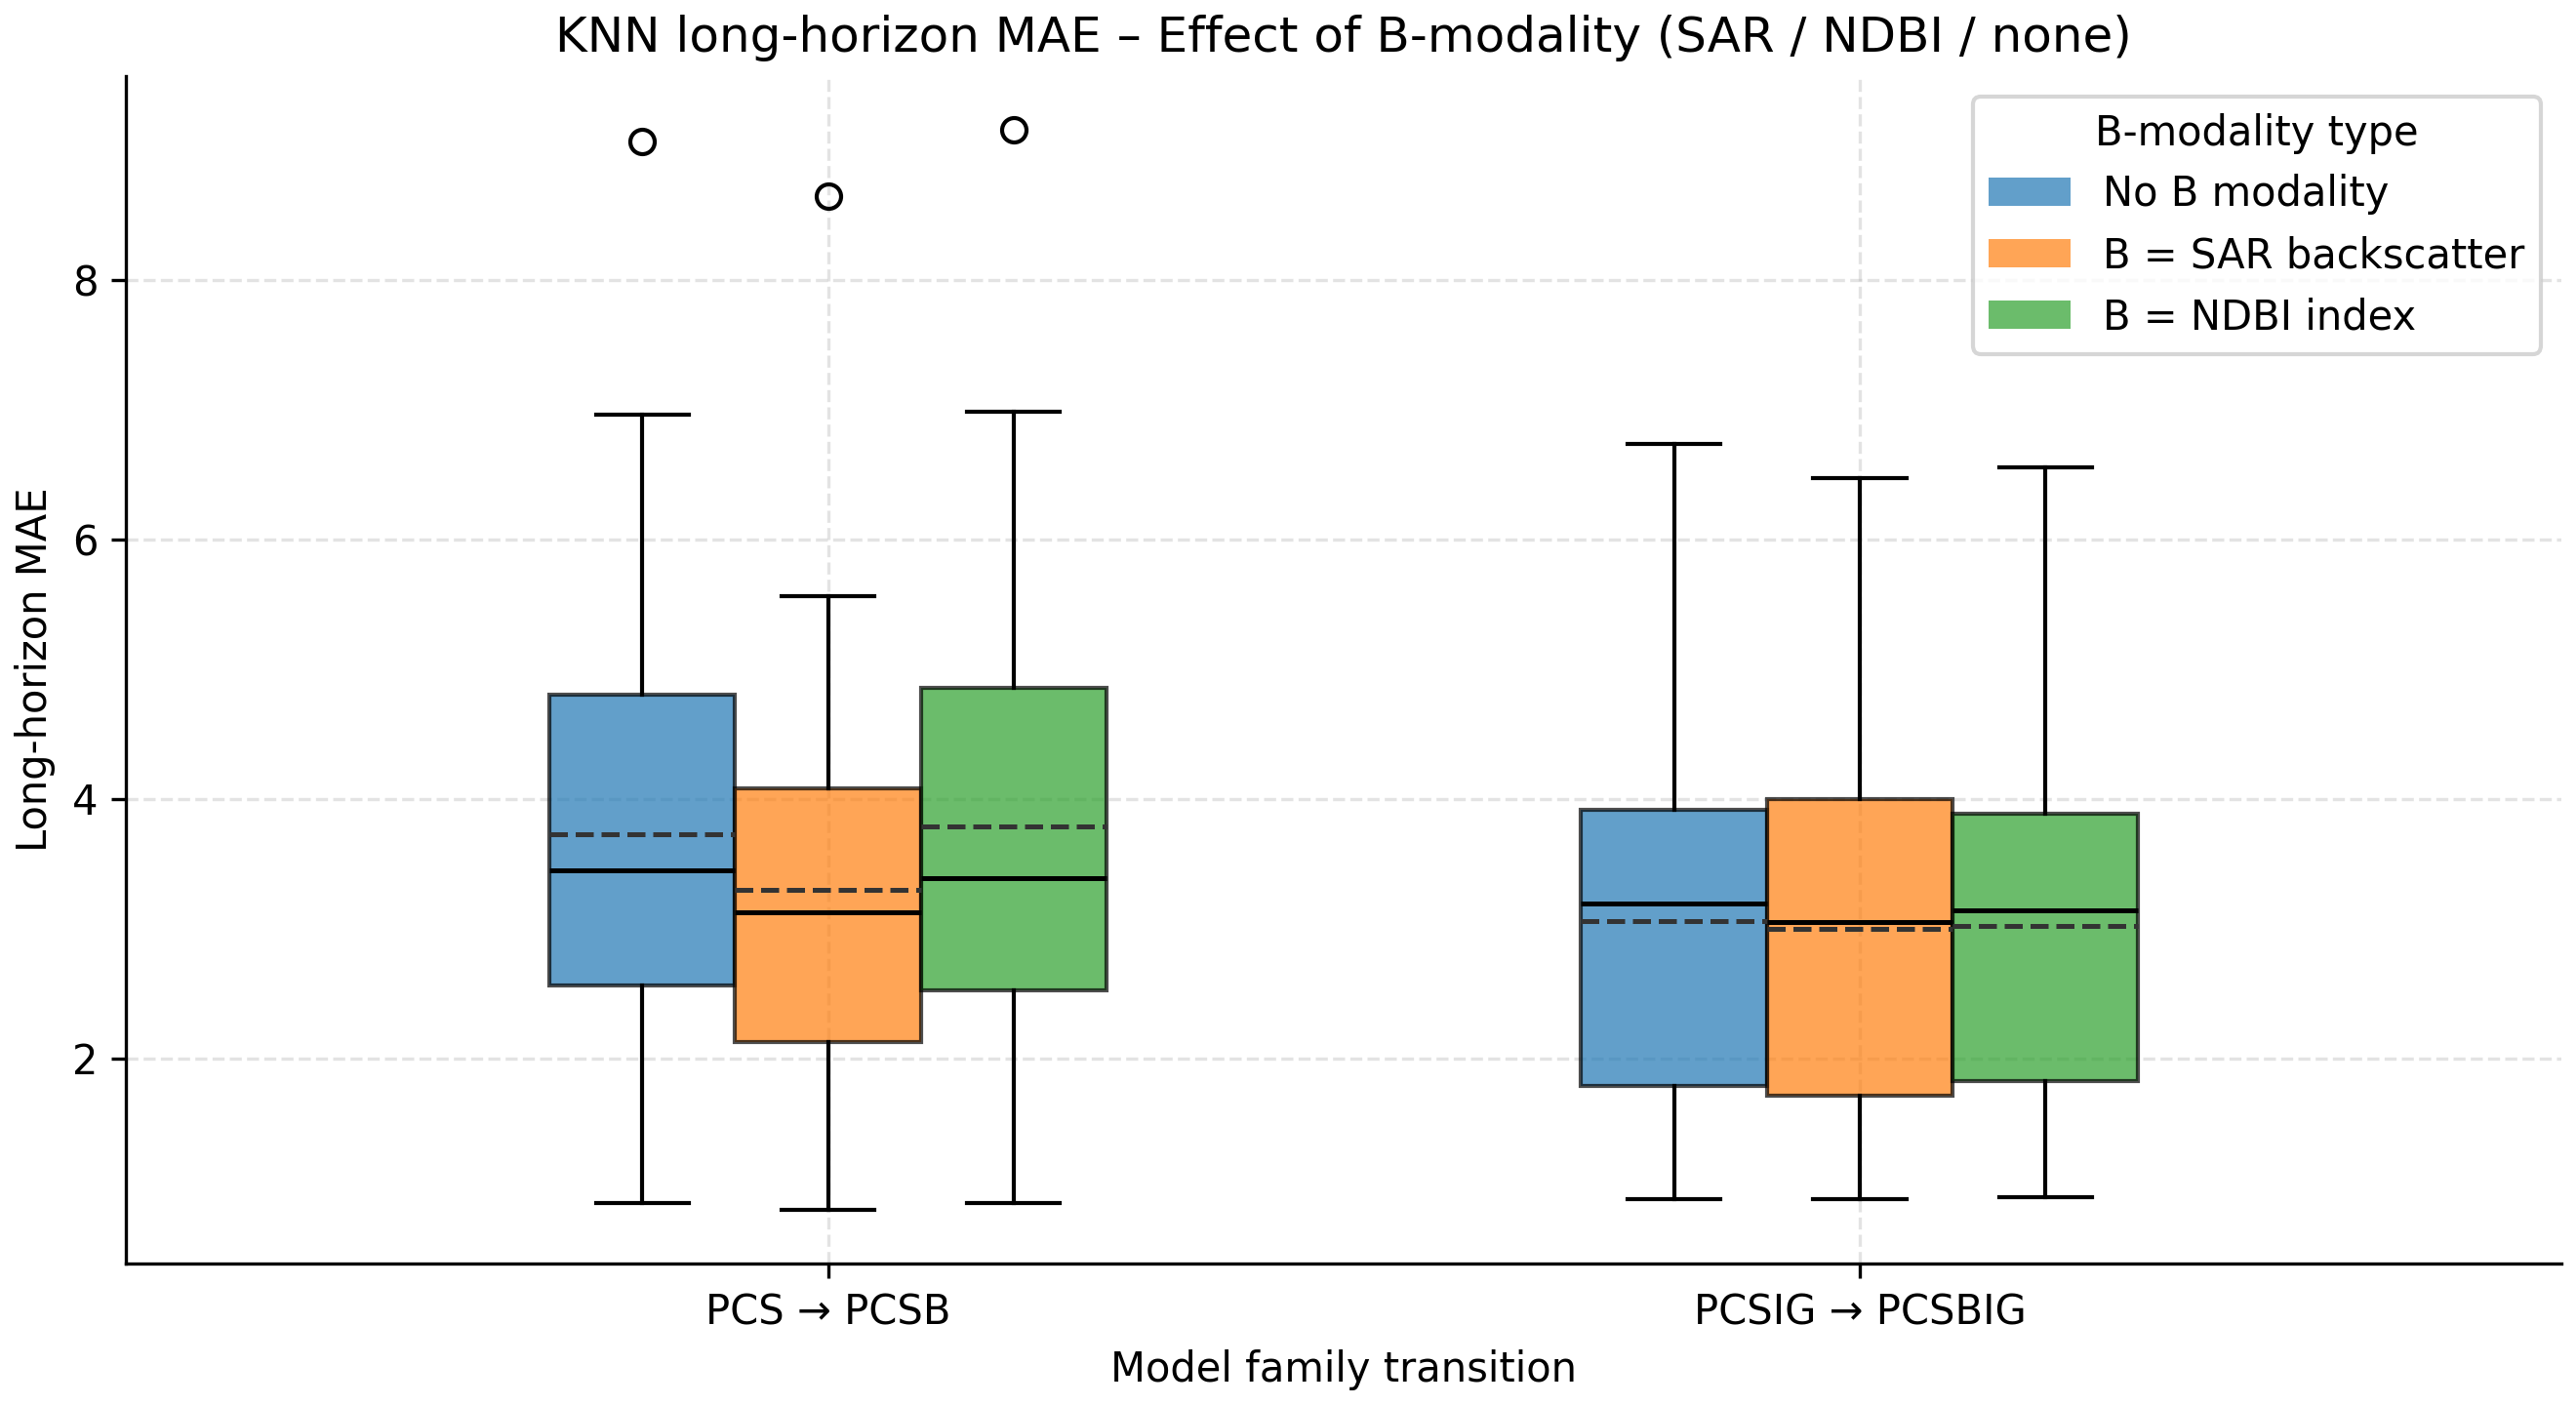

Saved B-modality ablation figure to: C:\Projects\multimodal_realestate_ml_public\paper_exports\figures\knn_b_modality_ablation.png


In [ ]:
configs_pcs_block = ["PCS", "PCSB_SAR", "PCSB_NDBI"]
configs_big_block = ["PCSBIG_noB", "PCSBIG_SAR", "PCSBIG_NDBI"]

df_long = (
    df_knn_b_ablation
    .groupby(["config", "region"], as_index=False)["mae_mean"]
    .mean()
    .rename(columns={"mae_mean": "mae"})
)

def get_data_for_configs(cfg_list):
    return [df_long[df_long["config"] == cfg]["mae"].values for cfg in cfg_list]

data_pcs_block = get_data_for_configs(configs_pcs_block)
data_big_block = get_data_for_configs(configs_big_block)

fig, ax = plt.subplots(figsize=(9, 5))

x_centers = np.array([0.0, 1.0])
width = 0.18

pos_pcs = x_centers[0] + np.array([-width, 0.0, width])
pos_big = x_centers[1] + np.array([-width, 0.0, width])

colors = plt.colormaps["tab10"].colors
color_noB = colors[0]
color_sar = colors[1]
color_ndbi = colors[2]

bp_pcs = ax.boxplot(
    data_pcs_block,
    positions=pos_pcs,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

bp_big = ax.boxplot(
    data_big_block,
    positions=pos_big,
    widths=width,
    patch_artist=True,
    showmeans=True,
    meanline=True,
    medianprops={"color": "black", "linewidth": 1.2},
    meanprops={"color": "#333333", "linewidth": 1.2}
)

for patch in bp_pcs["boxes"]:
    patch.set_alpha(0.7)
for patch in bp_big["boxes"]:
    patch.set_alpha(0.7)

bp_pcs["boxes"][0].set_facecolor(color_noB)
bp_pcs["boxes"][1].set_facecolor(color_sar)
bp_pcs["boxes"][2].set_facecolor(color_ndbi)

bp_big["boxes"][0].set_facecolor(color_noB)
bp_big["boxes"][1].set_facecolor(color_sar)
bp_big["boxes"][2].set_facecolor(color_ndbi)

ax.set_xticks(x_centers)
ax.set_xticklabels(
    ["PCS → PCSB", "PCSIG → PCSBIG"],
    rotation=0
)

ax.set_xlabel("Model family transition")
ax.set_ylabel("Long-horizon MAE")
ax.set_title("KNN long-horizon MAE – Effect of B-modality (SAR / NDBI / none)")

handles = [
    mpl.patches.Patch(facecolor=color_noB, alpha=0.7, label="No B modality"),
    mpl.patches.Patch(facecolor=color_sar, alpha=0.7, label="B = SAR backscatter"),
    mpl.patches.Patch(facecolor=color_ndbi, alpha=0.7, label="B = NDBI index")
]
ax.legend(handles=handles, title="B-modality type", loc="upper right")

plt.tight_layout()

EXPORT_ROOT = Path("paper_exports")
EXPORT_FIGS = EXPORT_ROOT / "figures"
for p in [EXPORT_ROOT, EXPORT_FIGS]:
    p.mkdir(parents=True, exist_ok=True)

outfile = EXPORT_FIGS / "knn_b_modality_ablation.png"
fig.savefig(outfile, bbox_inches="tight")
plt.show()
fig.savefig(outfile, dpi=900, format="png", bbox_inches="tight", pad_inches=0.05)
plt.close(fig)

print("Saved B-modality ablation figure to:", outfile.resolve())


In [ ]:
from scipy import stats

df_long = (
    df_knn_b_ablation
    .groupby(["config", "region"], as_index=False)["mae_mean"]
    .mean()
    .rename(columns={"mae_mean": "mae"})
)

pivot = df_long.pivot(index="region", columns="config", values="mae")

def one_sided_paired_t(alt, base):
    mask = np.isfinite(alt) & np.isfinite(base)
    alt_v = alt[mask]
    base_v = base[mask]
    if alt_v.size == 0:
        return np.nan, np.nan, 0
    t_res = stats.ttest_rel(alt_v, base_v)
    diff_mean = float(np.mean(alt_v - base_v))
    p_two = float(t_res.pvalue)
    if diff_mean < 0:
        p_one = p_two / 2.0
    else:
        p_one = 1.0 - p_two / 2.0
    return diff_mean, p_one, alt_v.size

tests = []

if {"PCS", "PCSB_SAR"}.issubset(pivot.columns):
    diff_mean, p_one, n = one_sided_paired_t(pivot["PCSB_SAR"].to_numpy(), pivot["PCS"].to_numpy())
    tests.append({
        "block": "PCS block (P,C,S)",
        "comparison": "B = SAR vs no B (PCS)",
        "n_regions": n,
        "mean_diff_alt_minus_base": diff_mean,
        "p_one_sided_alt_lower": p_one
    })

if {"PCS", "PCSB_NDBI"}.issubset(pivot.columns):
    diff_mean, p_one, n = one_sided_paired_t(pivot["PCSB_NDBI"].to_numpy(), pivot["PCS"].to_numpy())
    tests.append({
        "block": "PCS block (P,C,S)",
        "comparison": "B = NDBI vs no B (PCS)",
        "n_regions": n,
        "mean_diff_alt_minus_base": diff_mean,
        "p_one_sided_alt_lower": p_one
    })

if {"PCSBIG_noB", "PCSBIG_SAR"}.issubset(pivot.columns):
    diff_mean, p_one, n = one_sided_paired_t(pivot["PCSBIG_SAR"].to_numpy(), pivot["PCSBIG_noB"].to_numpy())
    tests.append({
        "block": "PCSBIG block (P,C,S,I,G)",
        "comparison": "B = SAR vs no B (PCSBIG)",
        "n_regions": n,
        "mean_diff_alt_minus_base": diff_mean,
        "p_one_sided_alt_lower": p_one
    })

if {"PCSBIG_noB", "PCSBIG_NDBI"}.issubset(pivot.columns):
    diff_mean, p_one, n = one_sided_paired_t(pivot["PCSBIG_NDBI"].to_numpy(), pivot["PCSBIG_noB"].to_numpy())
    tests.append({
        "block": "PCSBIG block (P,C,S,I,G)",
        "comparison": "B = NDBI vs no B (PCSBIG)",
        "n_regions": n,
        "mean_diff_alt_minus_base": diff_mean,
        "p_one_sided_alt_lower": p_one
    })

df_b_tests = pd.DataFrame(tests)
print("B-modality paired t-tests (H1: alt MAE < baseline MAE):")
display(df_b_tests)


B-modality paired t-tests (H1: alt MAE < baseline MAE):


,block,comparison,n_regions,mean_diff_alt_minus_base,p_one_sided_alt_lower
0,"PCS block (P,C,S)",B = SAR vs no B (PCS),20,-0.429366,0.000182
1,"PCS block (P,C,S)",B = NDBI vs no B (PCS),20,0.057610,0.935388
2,"PCSBIG block (P,C,S,I,G)",B = SAR vs no B (PCSBIG),20,-0.056699,0.042017
3,"PCSBIG block (P,C,S,I,G)",B = NDBI vs no B (PCSBIG),20,-0.035697,0.018495
